# Paired augmentation for roof segmentation

This notebook implements section 2 of `../method.docx` using the outputs of the data preparation notebook. The examples, measurements and verification results below have been executed on the supplied data. This notebook does not train a model or alter the source/prepared data.

**Inputs:** `data_preparation_outputs/manifest.csv`, `rgb`, `roof_masks`, and `validity_masks`. Only `usable_labelled` samples can enter supervised splits: 24 pairs at the time of this run. `278` remains quarantined.

**Baseline policy**

| Operation | Training | Validation / prediction |
|---|---|---|
| Horizontal flip | Probability 0.5 | Off |
| Vertical flip | Probability 0.5 | Off |
| Rotation | Uniform 0, 90, 180, 270 degrees counterclockwise | Off |
| Brightness and contrast | Applied together with probability 0.8; independent factors from 0.9 to 1.1 | Off |
| Geometry on roof/validity masks | Exactly the same as RGB | No change |
| ImageNet normalization | After augmentation | Same fixed normalization |

Quarter-turns and flips permute pixels exactly, so there is no resampling or padding. Masks stay binary and 256 × 256. Combinations yield eight distinct square symmetries; some parameter combinations are equivalent. Colour changes affect only RGB. Contrast is centred on the mean RGB of valid pixels, then brightness is applied. Invalid RGB is reset to zero.

Mild crop/zoom is available as an optional experiment, described below. Strong scaling, arbitrary rotations, elastic/grid warping, noise and erasing remain deferred. If added later, use nearest-neighbour interpolation for discrete masks and mark padded regions invalid. The numerical probabilities and colour ranges are starting choices, not measured optimal settings.

Requirements: Python 3.10+, NumPy and Pillow in a Jupyter environment. Notebooks import reusable functions from `roof_utils`; `roof_utils/roof_augmentation.py` contains the identical reusable implementation for the next training notebook.


In [1]:
from pathlib import Path
import sys

# Allow imports when Jupyter starts in notebooks/ without an editable install.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "roof_utils").is_dir() and (p / "pyproject.toml").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
PATHS = load_paths(PROJECT_ROOT)

from roof_utils.augmentation_review import (inspect_prepared, show_geometry,
    show_random_examples, verify_augmentation, demonstrate_fold)
print("Prepared data:", PATHS.prepared_data_dir)


Prepared data: /Users/zkm/Desktop/dida_test_task/data_preparation_outputs


## 1 Reusable implementation

`augment` operates on uint8 RGB and 0/1 masks. It requires an explicit random generator for training; validation consumes no random numbers. `RoofFoldDataset` validates the split and looks up eligibility in the manifest. Samples are augmented during access instead of saving a finite augmented dataset to disk.

Randomness is keyed by seed, fold, epoch, original sample ID and optional view number. This keeps draws reproducible independently of worker order. Increment the epoch for new training draws. This guarantees reproducibility in the same dependency environment; keep the printed versions with experiment records.


In [2]:
from roof_utils.roof_augmentation import (AugmentConfig, augment, RoofFoldDataset)
print(AugmentConfig())


AugmentConfig(horizontal_flip_probability=0.5, vertical_flip_probability=0.5, rotate90=True, colour_probability=0.8, brightness_range=(0.9, 1.1), contrast_range=(0.9, 1.1), crop_probability=0.0, crop_side_range=(224, 256), min_crop_valid_fraction=0.7, crop_attempts=10)


In [3]:
inspect_prepared(PATHS.prepared_data_dir)


Manifest statuses: {'usable_labelled': 24, 'quarantined': 1, 'unlabelled': 5}
Usable labelled IDs: 121, 241, 270, 272, 274, 284, 287, 300, 301, 303, 308, 314, 315, 317, 320, 324, 328, 337, 343, 345, 379, 381, 417, 532
Validated exported RGB and binary masks for all 24 eligible pairs.
Spatial groups populated: 24
Configuration: AugmentConfig(horizontal_flip_probability=0.5, vertical_flip_probability=0.5, rotate90=True, colour_probability=0.8, brightness_range=(0.9, 1.1), contrast_range=(0.9, 1.1), crop_probability=0.0, crop_side_range=(224, 256), min_crop_valid_fraction=0.7, crop_attempts=10)


## 2 See the transformations

Each row shows RGB, red roof overlay, binary target and validity. Grey checkerboard marks invalid areas in the visualizations only. The actual model input uses a zero RGB fill there. Compare the transformed missing regions as well as the roof edges.

The first examples force individual geometry operations for clarity. The following examples use the actual random baseline policy. Pixel area should remain unchanged for roof and validity masks because these transforms do not crop or interpolate.


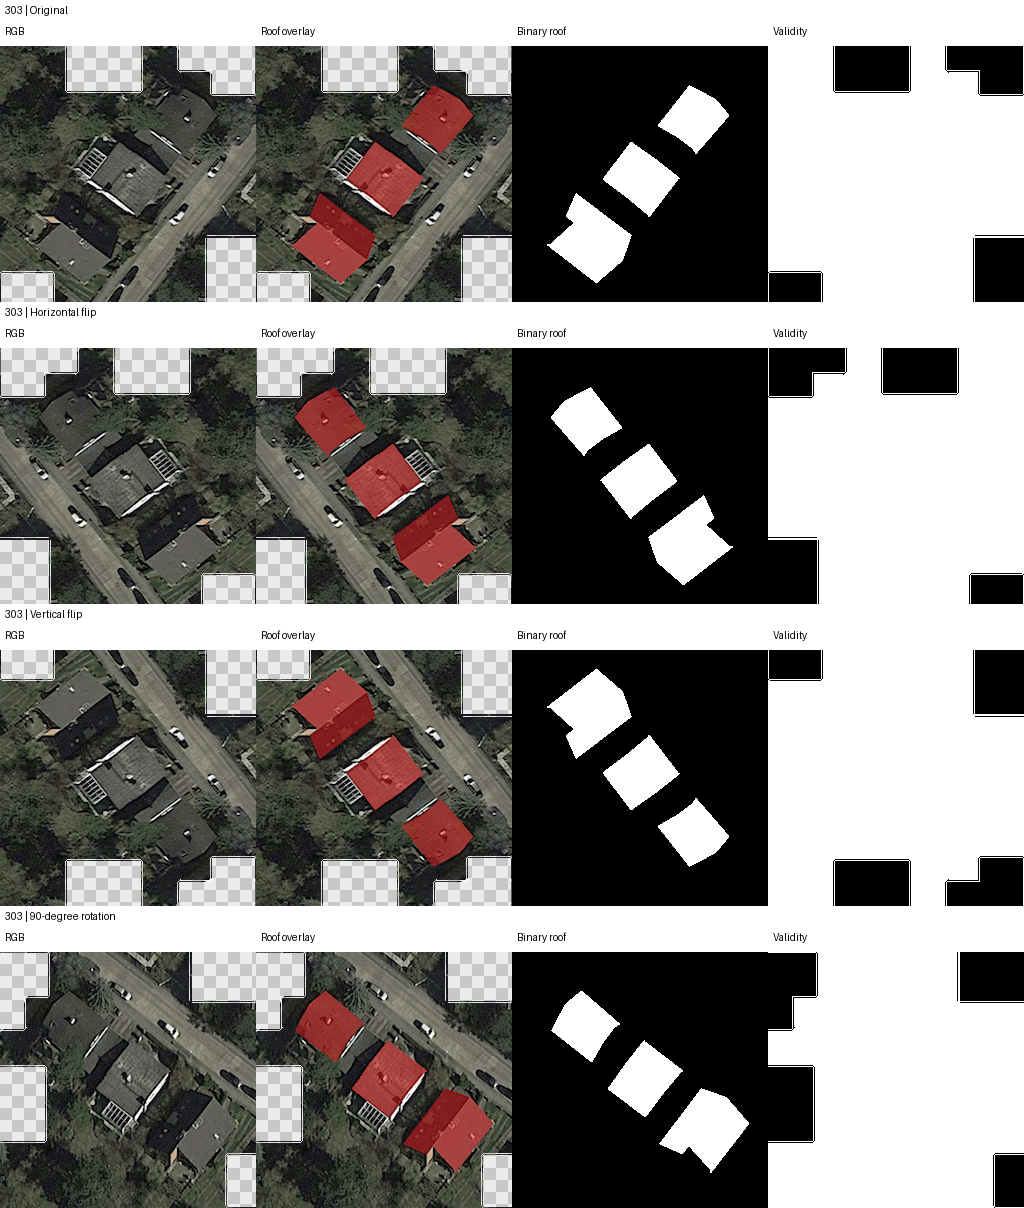

In [4]:
show_geometry(PATHS.prepared_data_dir)


Sample 270:
270 | epoch 0: rot=270, H=False, V=False, brightness=1.000, contrast=1.000
270 | epoch 1: rot=0, H=False, V=True, brightness=0.995, contrast=1.036
270 | epoch 2: rot=270, H=False, V=False, brightness=1.050, contrast=1.074


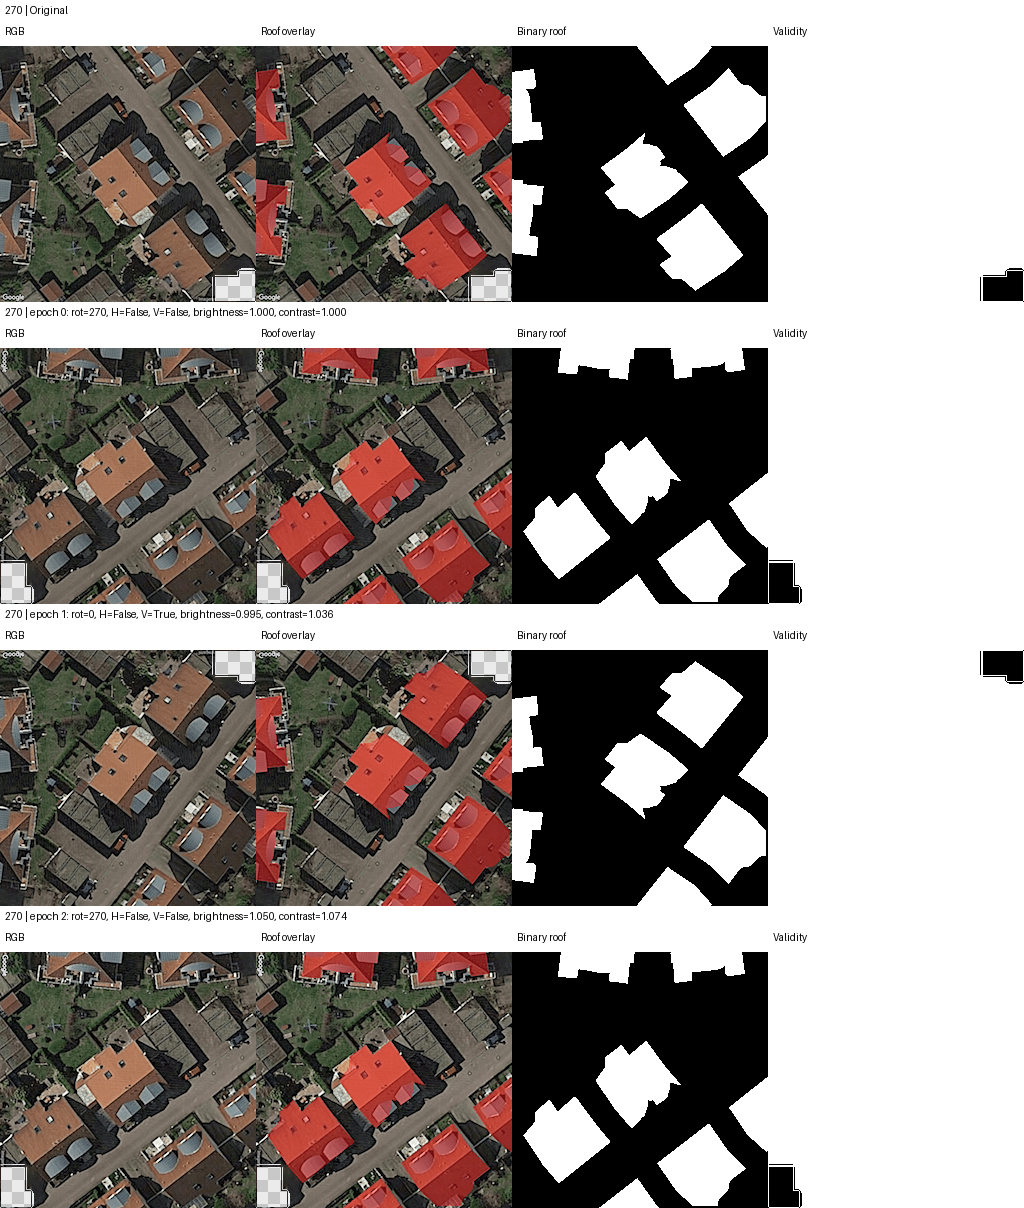

Sample 532:
532 | epoch 0: rot=90, H=False, V=False, brightness=0.975, contrast=0.972
532 | epoch 1: rot=270, H=True, V=True, brightness=1.091, contrast=1.062
532 | epoch 2: rot=0, H=True, V=False, brightness=1.009, contrast=0.954


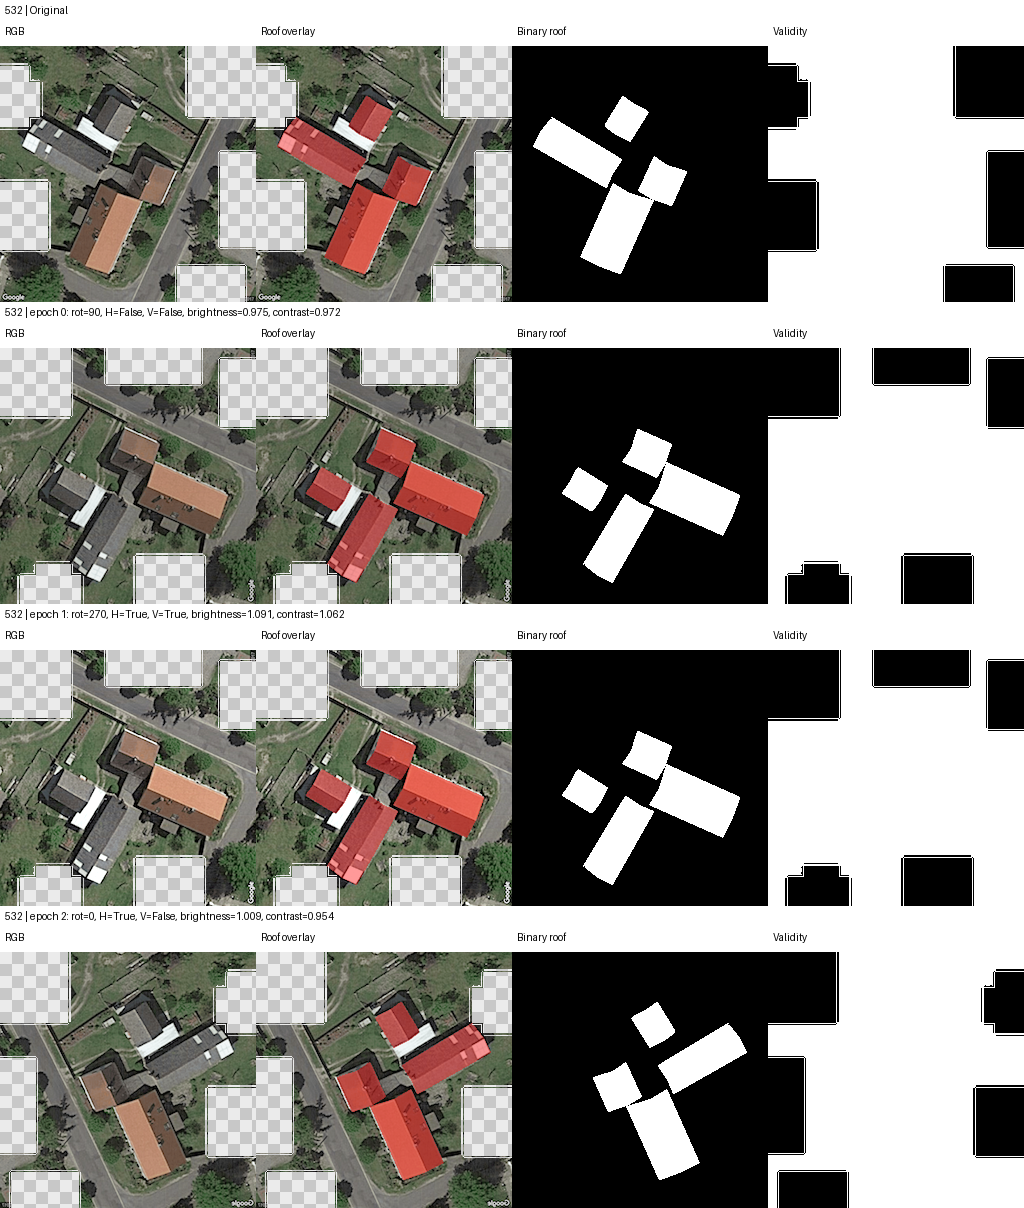

In [5]:
show_random_examples(PATHS.prepared_data_dir)


## 3 Check alignment and reproducibility

The synthetic test places known target and validity patterns into RGB channels and checks that they stay pixel-aligned for every rotation/flip combination. Dataset-wide checks verify mask areas, binary values, fixed dimensions, invalid-region handling and that source arrays are not mutated. Colour-only tests verify that both masks stay unchanged. Repeating a seed must reproduce the same output; validation must be identical across epochs.


In [6]:
verify_augmentation(PATHS.prepared_data_dir)


PASS: all 16 geometry parameter combinations preserve phantom alignment.
PASS: 240 augmented real samples preserve area, binary masks, dimensions and source arrays.
PASS: same seed reproduces output; another epoch changes this example draw.
PASS: colour-only augmentation changes RGB and preserves both masks.
PASS: validation preprocessing preserves every prepared sample before normalization.


## Optional mild crop and zoom experiment

Enable with `AugmentConfig(crop_probability=0.3)`; the default remains 0 to preserve the baseline. In training, after flips/quarter-turns and before colour changes, attempt a crop with probability 30%. Draw an integer square side uniformly from 224–256 pixels, and a position uniformly among those that fit. Resize to 256 × 256: zoom ranges from 1.0 to about 1.14×. Selecting side 256 is a valid identity crop.

Require at least 70% valid pixels in the crop; retry at most 10 times, then keep the uncropped geometric result. The acceptance filter can make the effective cropping rate less than 30%. There is no roof-presence requirement: background-only examples remain useful.

RGB uses bilinear interpolation weighted by validity to prevent missing black pixels from darkening valid boundaries. Roof and validity masks use nearest-neighbour interpolation. Reset invalid RGB and target pixels to zero. No padding, elastic warping or grid distortion is introduced. Validation and inference do not crop.

Crop/resize changes visible area and pixel counts. Area-preservation assertions apply only to the old flips/quarter-turns baseline; crop checks instead compare transformed masks against the recorded crop coordinates and nearest-neighbour reference. Spatial alignment, binary values, validity, reproducibility and unchanged validation remain required.

The visual examples force crop probability to 1 for illustration; the fold demonstration uses the intended 0.3 configuration. These are implementation checks, not evidence of model improvement.


AugmentConfig(horizontal_flip_probability=0.5, vertical_flip_probability=0.5, rotate90=True, colour_probability=0.8, brightness_range=(0.9, 1.1), contrast_range=(0.9, 1.1), crop_probability=0.3, crop_side_range=(224, 256), min_crop_valid_fraction=0.7, crop_attempts=10)
303 | crop box=(0, 0, 251, 251), zoom=1.020x
303 | crop box=(13, 0, 249, 236), zoom=1.085x
303 | crop box=(7, 8, 239, 240), zoom=1.103x


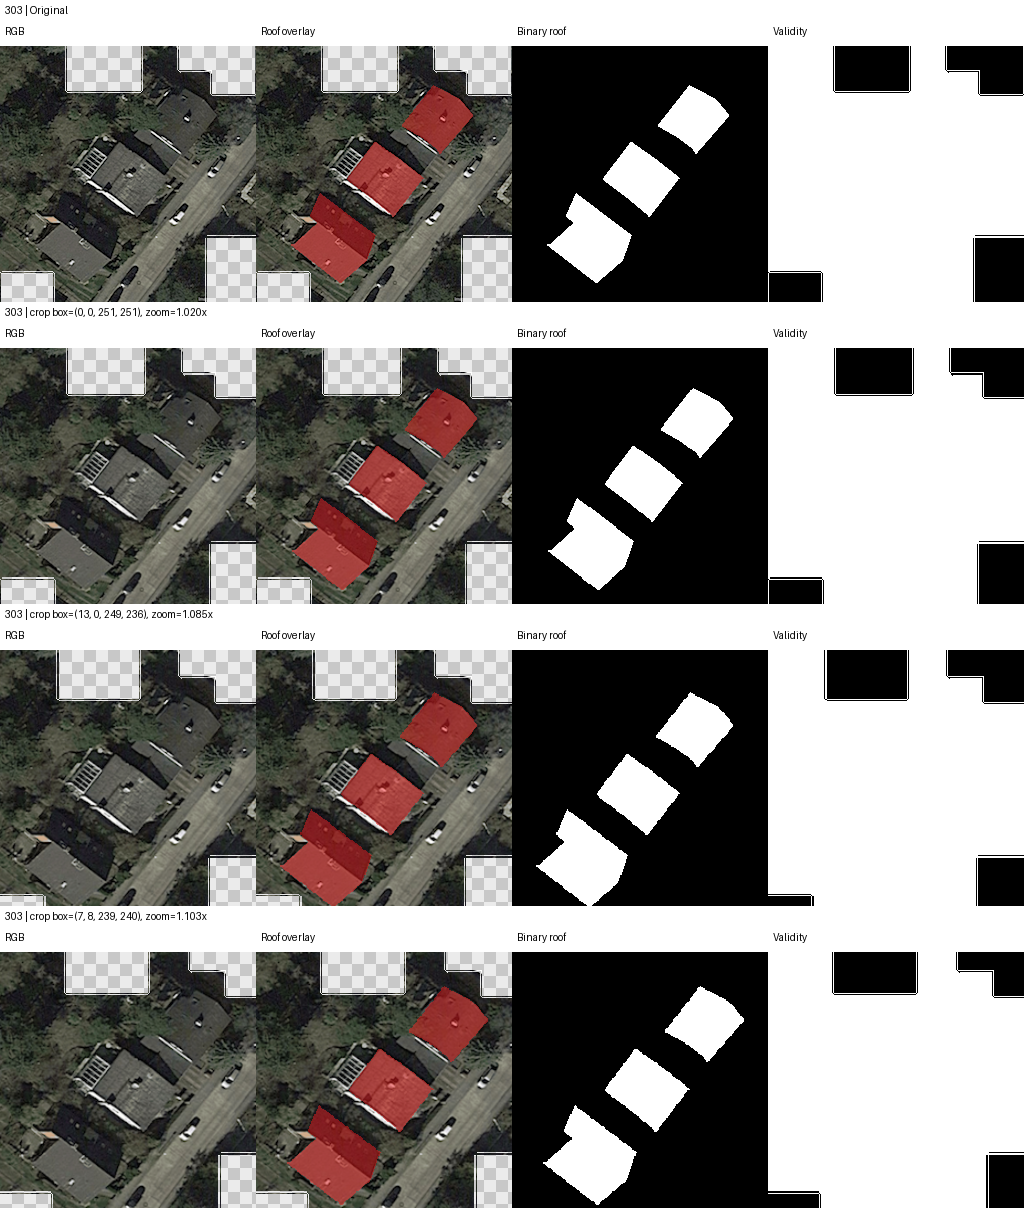

532 | crop box=(0, 0, 256, 256), zoom=1.000x
532 | crop box=(7, 20, 237, 250), zoom=1.113x
532 | crop box=(1, 1, 256, 256), zoom=1.004x


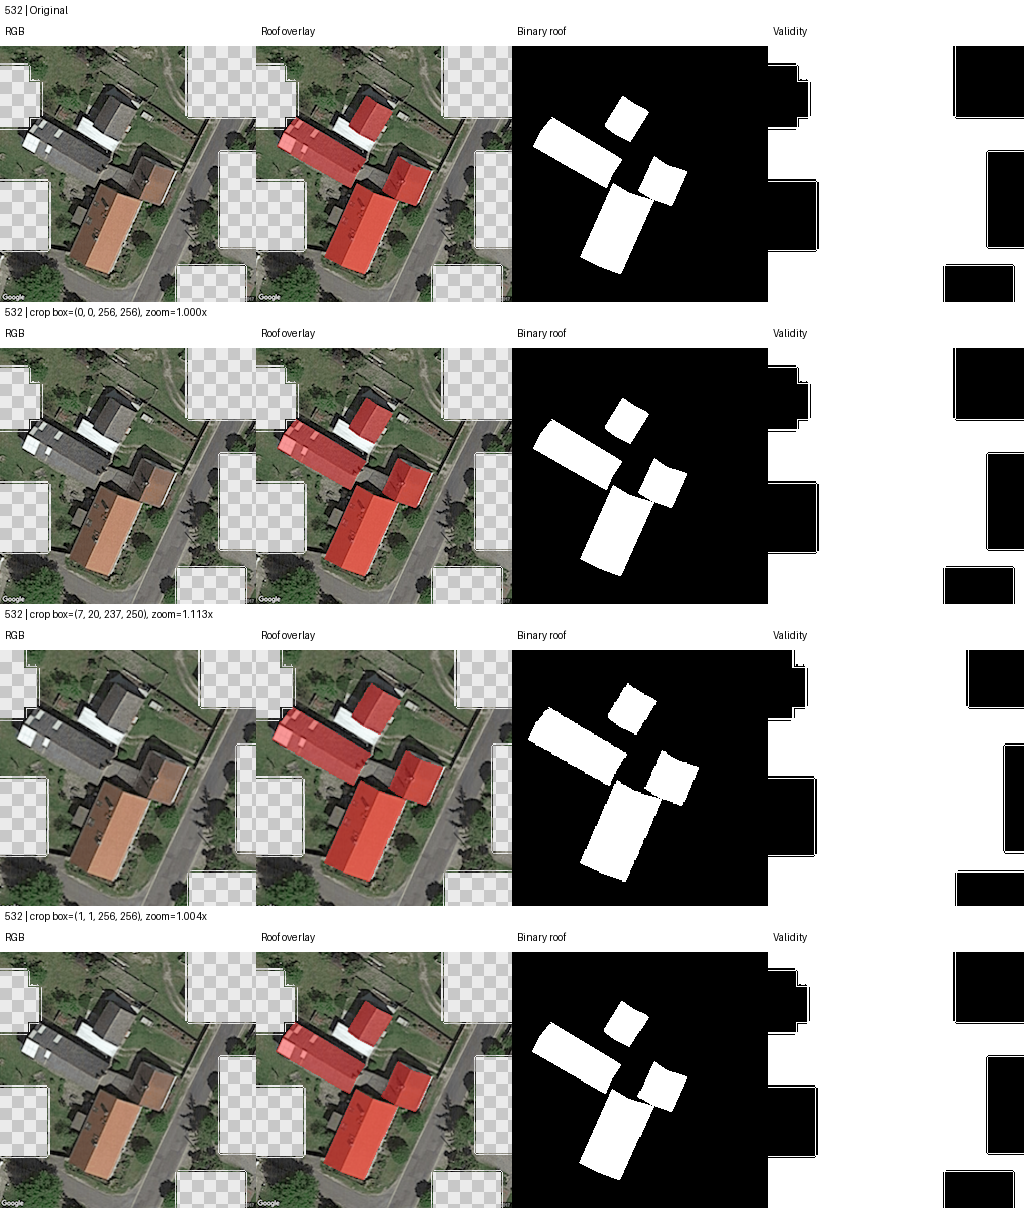

PASS: crop experiment on real samples: {'samples': 240, 'requested': 63, 'accepted': 63, 'fallbacks': 0}
PASS: exact mask reference, binary values, validity, reproducibility and unchanged validation.
PASS: synthetic RGB square and roof mask remain aligned after resizing.
PASS: no dark interpolation halo; bounded fallback when valid coverage is insufficient.
PASS: background-only crop accepted.


In [7]:
from roof_utils.augmentation_review import show_crop_examples, verify_crop_augmentation
CROP_CONFIG = AugmentConfig(crop_probability=0.3)
print(CROP_CONFIG)
show_crop_examples(PATHS.prepared_data_dir)
verify_crop_augmentation(PATHS.prepared_data_dir)


## 4 Use the frozen development folds

The split review and frozen assignments are in `../splits/README.md` and `validation_folds.json`. Use fold 0 below rather than generating a fresh random split. Each sample has a visually reviewed scene ID, but geographical independence is unknown. These are development folds, not an independent test.

The loader checks data fingerprints and coverage before returning IDs. Apply training augmentation only after loading the split. The example uses `CROP_CONFIG`; use `AugmentConfig()` for the unchanged baseline on the same folds.


In [8]:
from roof_utils.validation_splits import load_fold
train_ids, val_ids = load_fold(PATHS, fold=0)
train_ds = RoofFoldDataset(PATHS.prepared_data_dir, train_ids, val_ids, split="train", config=CROP_CONFIG)
val_ds = RoofFoldDataset(PATHS.prepared_data_dir, train_ids, val_ids, split="val", config=CROP_CONFIG)
print("Frozen fold 0: training", len(train_ds), "validation", len(val_ds))
print("Validation IDs:", val_ids)
print("Geographical independence remains unknown; see splits/README.md.")


Frozen fold 0: training 20 validation 4
Validation IDs: ['121', '241', '328', '417']
Geographical independence remains unknown; see splits/README.md.


### Using the dataset in the later training notebook

The dataset implements the map-style interface, so a PyTorch DataLoader can collate its NumPy arrays into tensors. PyTorch integration is not executed here; no network is trained in this notebook.

```python
from torch.utils.data import DataLoader
from roof_utils.roof_augmentation import RoofFoldDataset

# Supply reviewed train_ids and val_ids for this fold.
train_ds = RoofFoldDataset(PATHS.prepared_data_dir, train_ids, val_ids, split="train", seed=42, fold=fold)
val_ds = RoofFoldDataset(PATHS.prepared_data_dir, train_ids, val_ids, split="val", seed=42, fold=fold)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0)

for epoch in range(num_epochs):
    train_ds.set_epoch(epoch)
    for batch in train_loader:
        # batch["image"], batch["target"], batch["valid"] go to the training device.
        # Use unreduced BCE, mask by valid, then divide by the valid-pixel count.
        # Mask both probabilities and targets in the Dice numerator/denominator.
        pass
```

Start with `num_workers=0`. When adding workers, keep `persistent_workers=False` so updated epoch values reach workers when a new iterator starts. This implementation returns the same augmentation for a sample accessed twice within one epoch; use `get(index, view=...)` for explicit multiple views. Seed the training model and DataLoader shuffling separately for complete experiment reproducibility.

## Result and next experiment

The displayed checks verify that the augmentation mechanism preserves paired labels and validity while producing reproducible variation. They do **not** establish an accuracy gain. On the same reviewed folds, compare the existing flips/rotations/colour baseline against that baseline plus mild crop/zoom. Keep model settings fixed and compare per-fold roof IoU and failure overlays. No extra independent images have been created.

References: [NumPy random generators](https://numpy.org/doc/stable/reference/random/generator.html), [NumPy quarter-turn rotations](https://numpy.org/doc/stable/reference/generated/numpy.rot90.html), and [torchvision ResNet18 normalization](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html).
